# ============================================
# IMPORT LIBRARIES
# ============================================


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================
# LOAD DATASET
# ============================================

In [27]:
df = pd.read_csv("/kaggle/input/datasets/helenelsabinu/students-performance/StudentsPerformance.csv")
print(df)
print("Dataset Loaded Successfully")

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

# ============================================
# DISPLAY FIRST 5 ROWS
# ============================================

In [28]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


# ============================================
# DATA PREPROCESSING
# ============================================

In [29]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["result"] = df["average_score"].apply(lambda x: 1 if x >= 50 else 0)

In [30]:
# Encode categorical columns

label_encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])


# ============================================
# SELECT FEATURES & TARGET
# ============================================

In [31]:
X = df.drop(["result", "average_score"], axis=1)
y = df["result"]

# ============================================
# SPLIT DATA
# ============================================


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# ============================================
# TRAIN MACHINE LEARNING MODEL
# ============================================


In [33]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# ============================================
# PREDICTIONS
# ============================================


In [34]:
y_pred = model.predict(X_test)

# ============================================
# MODEL ACCURACY
# ============================================


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(round(accuracy * 100, 2), "%")


Model Accuracy:
99.5 %


# ============================================
# CLASSIFICATION REPORT
# ============================================




In [36]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.99      1.00      1.00       173

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



# ============================================
# CONFUSION MATRIX
# ============================================


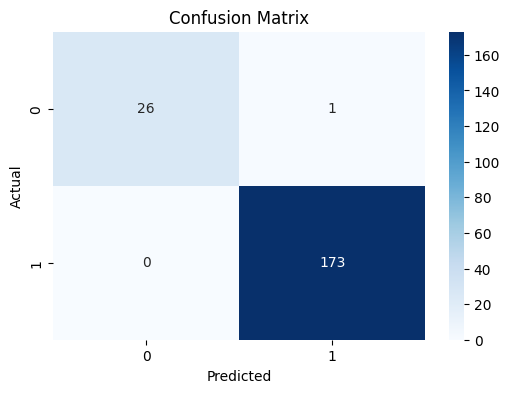

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================
# FEATURE IMPORTANCE GRAPH
# ============================================

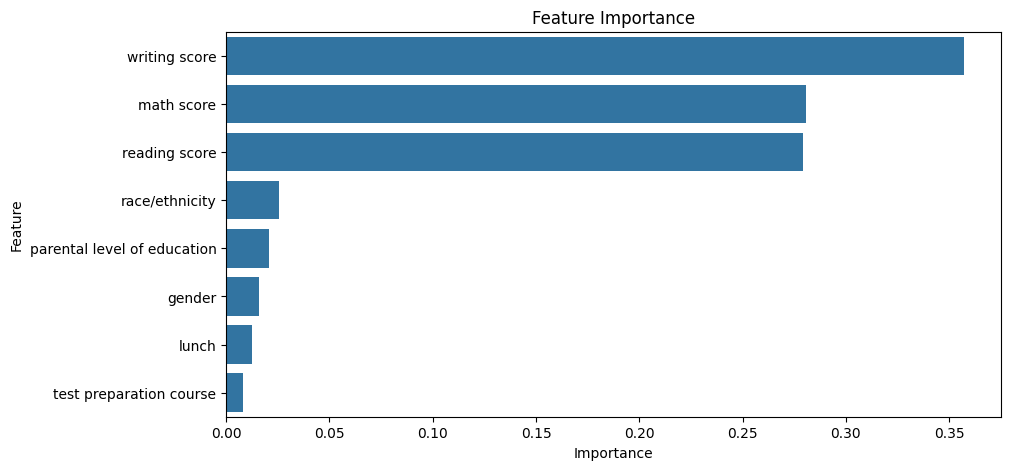

In [38]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

# ============================================
# GRADIO ADVANCED INTERFACE
# ============================================


In [39]:
def predict_student(
    gender,
    race,
    parent_education,
    lunch,
    preparation,
    math_score,
    reading_score,
    writing_score
):

    # Encode manually

    gender_map = {
        "female": 0,
        "male": 1
    }

    race_map = {
        "group A": 0,
        "group B": 1,
        "group C": 2,
        "group D": 3,
        "group E": 4
    }

    education_map = {
        "some high school": 0,
        "high school": 1,
        "some college": 2,
        "associate's degree": 3,
        "bachelor's degree": 4,
        "master's degree": 5
    }

    lunch_map = {
        "free/reduced": 0,
        "standard": 1
    }

    prep_map = {
        "none": 0,
        "completed": 1
    }

    # Create input array

    input_data = np.array([[
        gender_map[gender],
        race_map[race],
        education_map[parent_education],
        lunch_map[lunch],
        prep_map[preparation],
        math_score,
        reading_score,
        writing_score
    ]])

    # Prediction

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0]

    confidence = round(max(probability) * 100, 2)

    if prediction == 1:
        result = "PASS"
    else:
        result = "FAIL"

    return f"""
    Prediction Result: {result}

    Confidence Level: {confidence}%
    """

# ============================================
# ADVANCED UI DESIGN
# ============================================

In [40]:
title = "🎓 Student Performance Prediction System"

description = """
This Machine Learning model predicts whether a student will PASS or FAIL
based on exam scores and personal information.

Developed using:
- Python
- Scikit-Learn
- Random Forest Classifier
- Gradio Interface
"""

interface = gr.Interface(
    fn=predict_student,

    inputs=[

        gr.Dropdown(
            ["female", "male"],
            label="Gender"
        ),

        gr.Dropdown(
            ["group A", "group B", "group C", "group D", "group E"],
            label="Race/Ethnicity"
        ),

        gr.Dropdown(
            [
                "some high school",
                "high school",
                "some college",
                "associate's degree",
                "bachelor's degree",
                "master's degree"
            ],
            label="Parental Education"
        ),

        gr.Dropdown(
            ["free/reduced", "standard"],
            label="Lunch Type"
        ),

        gr.Dropdown(
            ["none", "completed"],
            label="Test Preparation"
        ),

        gr.Slider(
            0,
            100,
            step=1,
            label="Math Score"
        ),

        gr.Slider(
            0,
            100,
            step=1,
            label="Reading Score"
        ),

        gr.Slider(
            0,
            100,
            step=1,
            label="Writing Score"
        )
    ],

    outputs=gr.Textbox(label="Prediction"),

    title=title,

    description=description,

    theme="soft",

    allow_flagging="never"
)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


# ============================================
# LAUNCH APPLICATION
# ============================================


In [41]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://db6f3df6c418807c98.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
